In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset (replace 'crime_new.csv' with the correct file path)
crime_data = pd.read_csv(r"C:\Users\COE-27\Documents\ML\Crime data\crime_new.csv")


In [3]:
# Step 1: Basic Information
print("Dataset Info:")
print(crime_data.info())
print("\nSummary Statistics:")
print(crime_data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530652 entries, 0 to 530651
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           530652 non-null  object 
 1   YEAR           530652 non-null  int64  
 2   MONTH          530652 non-null  int64  
 3   DAY            530652 non-null  int64  
 4   HOUR           476290 non-null  float64
 5   MINUTE         476290 non-null  float64
 6   HUNDRED_BLOCK  530639 non-null  object 
 7   NEIGHBOURHOOD  474028 non-null  object 
 8   X              530652 non-null  float64
 9   Y              530652 non-null  float64
 10  Latitude       530652 non-null  float64
 11  Longitude      530652 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 48.6+ MB
None

Summary Statistics:
                YEAR          MONTH            DAY           HOUR  \
count  530652.000000  530652.000000  530652.000000  476290.000000   
mean     2009.1979

In [5]:
crime_data['HOUR'] = crime_data['HOUR'].fillna(crime_data['HOUR'].mean())
crime_data['MINUTE'] = crime_data['MINUTE'].fillna(crime_data['MINUTE'].mean())
crime_data['NEIGHBOURHOOD'] = crime_data['NEIGHBOURHOOD'].fillna('Unknown')
crime_data['HUNDRED_BLOCK'] = crime_data['HUNDRED_BLOCK'].fillna('Unknown Block')

C:\Users\COE-27\AppData\Local\Temp\ipykernel_8488\3676909998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, palette='viridis')


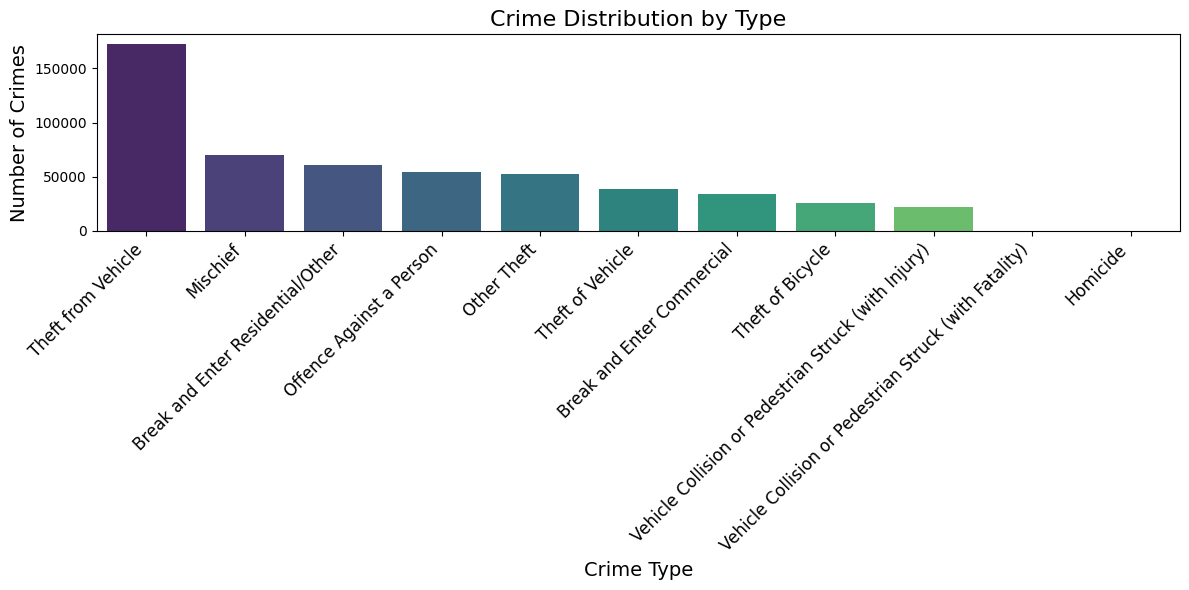

In [6]:
# Step 3: Crime Distribution by Type
plt.figure(figsize=(12, 6))
crime_type_counts = crime_data['TYPE'].value_counts()
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, palette='viridis')
plt.title('Crime Distribution by Type', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xlabel('Crime Type', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\COE-27\AppData\Local\Temp\ipykernel_8488\73894307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


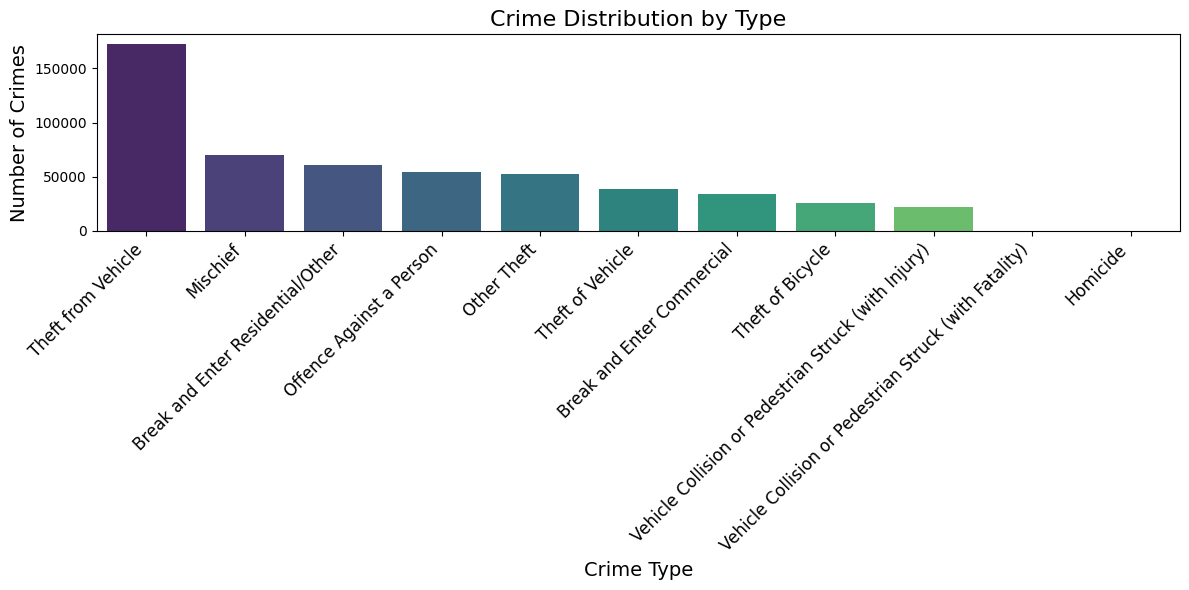

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Crime Distribution by Type
plt.figure(figsize=(12, 6))
crime_type_counts = crime_data['TYPE'].value_counts()

# Explicitly set hue=None and legend=False
sns.barplot(
    x=crime_type_counts.index, 
    y=crime_type_counts.values, 
    palette='viridis',
    hue=None  # Explicitly state no hue grouping
)

plt.title('Crime Distribution by Type', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xlabel('Crime Type', fontsize=14)
plt.tight_layout()
plt.show()




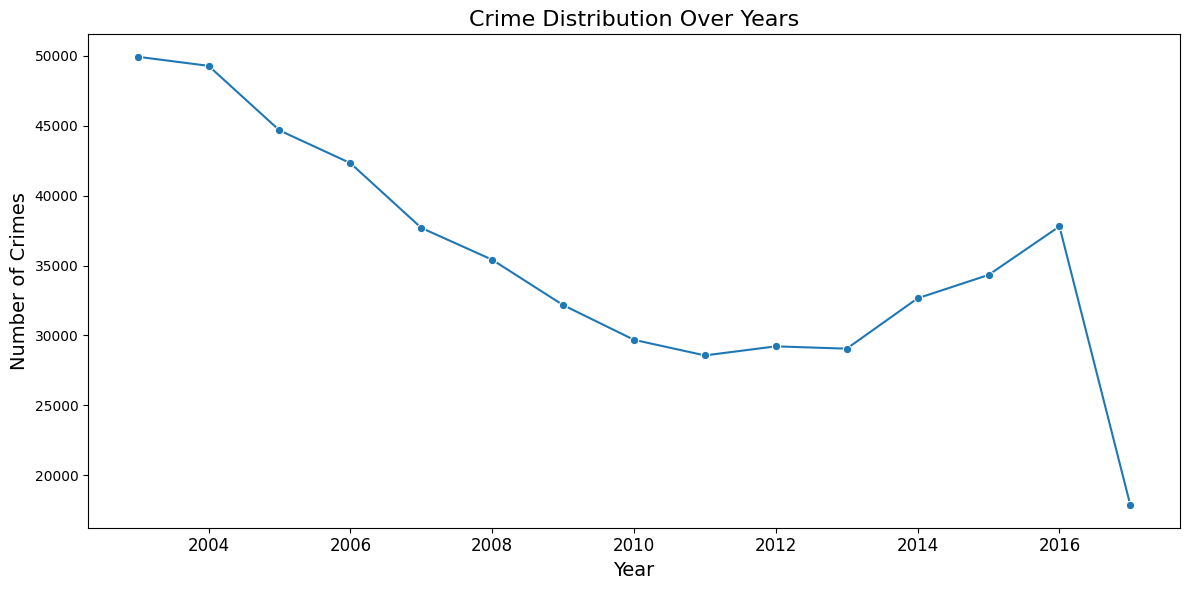

In [8]:
# Step 4: Crime Distribution Over Years
plt.figure(figsize=(12, 6))
crime_year_counts = crime_data['YEAR'].value_counts().sort_index()
sns.lineplot(x=crime_year_counts.index, y=crime_year_counts.values, marker='o')
plt.title('Crime Distribution Over Years', fontsize=16)
plt.xticks(fontsize=12)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.tight_layout()
plt.show()

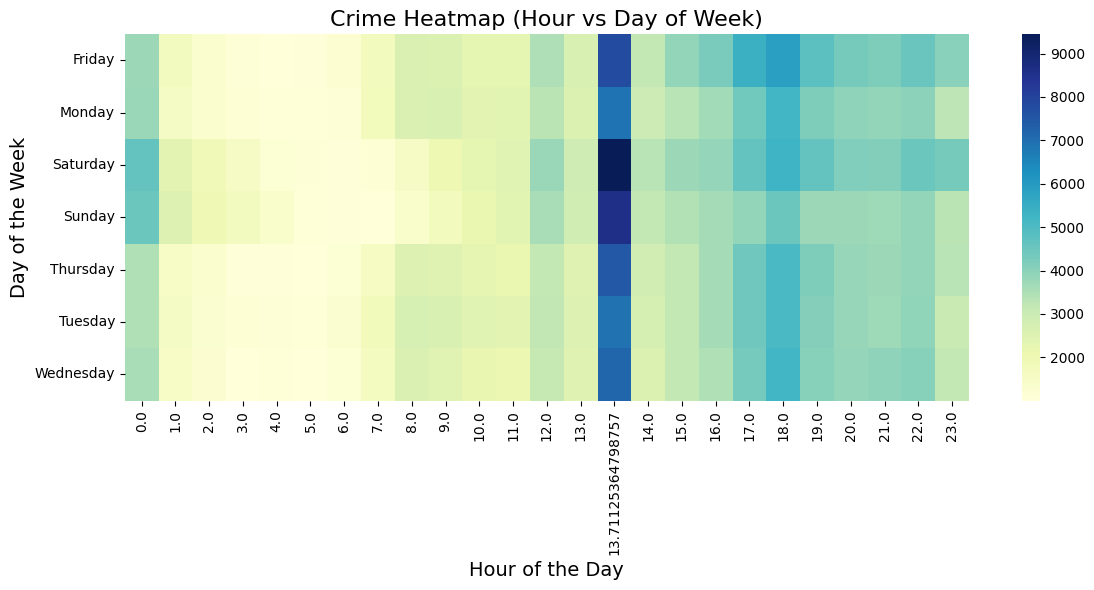

In [9]:
# Step 5: Crime Heatmap by Hour and Day
plt.figure(figsize=(12, 6))
crime_data['DAY_OF_WEEK'] = pd.to_datetime(crime_data[['YEAR', 'MONTH', 'DAY']]).dt.day_name()
hour_day_data = crime_data.groupby(['DAY_OF_WEEK', 'HOUR']).size().unstack()
sns.heatmap(hour_day_data, cmap='YlGnBu', annot=False)
plt.title('Crime Heatmap (Hour vs Day of Week)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Day of the Week', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Check for NaN values..Check for Missing or Invalid Data
print(crime_data[['Longitude', 'Latitude']].isnull().sum())

# Drop rows with missing values
crime_data = crime_data.dropna(subset=['Longitude', 'Latitude'])


#Inspect Value Ranges
print(crime_data['Longitude'].describe())
print(crime_data['Latitude'].describe())


#Handle Outliers
crime_data = crime_data[
    (crime_data['Longitude'] > -180) & (crime_data['Longitude'] < 180) &
    (crime_data['Latitude'] > -90) & (crime_data['Latitude'] < 90)
]

Longitude    0
Latitude     0
dtype: int64
count    530652.000000
mean       -110.495297
std          37.329862
min        -124.549757
25%        -123.127194
50%        -123.107128
75%        -123.065932
max           0.000000
Name: Longitude, dtype: float64
count    530652.000000
mean         44.216029
std          14.938004
min           0.000000
25%          49.235573
50%          49.264251
75%          49.280441
max          49.755314
Name: Latitude, dtype: float64


In [11]:
# Check for missing values
print(crime_data[['Longitude', 'Latitude']].isnull().sum())

# Drop rows with missing values
crime_data = crime_data.dropna(subset=['Longitude', 'Latitude'])


print(crime_data['Longitude'].nunique())
print(crime_data['Latitude'].nunique())


Longitude    0
Latitude     0
dtype: int64
98972
101885


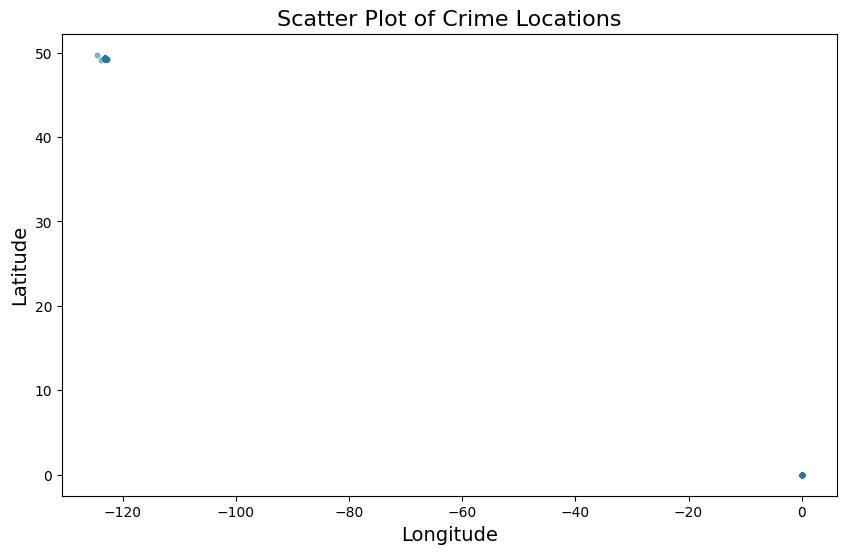

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(crime_data['Longitude'], crime_data['Latitude'], alpha=0.5, s=10)
plt.title('Scatter Plot of Crime Locations', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.show()


<Axes: xlabel='Longitude', ylabel='Latitude'>

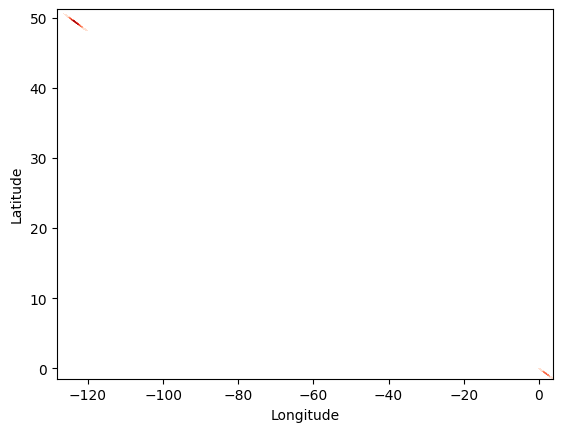

In [15]:
sns.kdeplot(
    x=crime_data['Longitude'], 
    y=crime_data['Latitude'], 
    cmap="Reds", 
    fill=True, 
    bw_adjust=0.3,
    thresh=0.01,
    gridsize=500  # Increase grid size for better density estimates
)


In [16]:
crime_data_filtered = crime_data[
    (crime_data['Longitude'] >= -125) & (crime_data['Longitude'] <= -65) &
    (crime_data['Latitude'] >= 25) & (crime_data['Latitude'] <= 50)
]


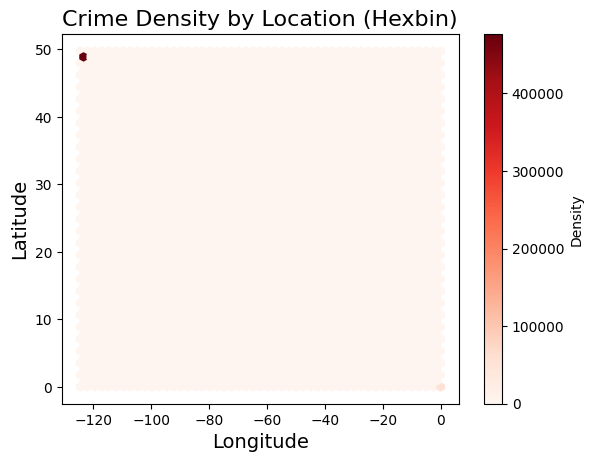

In [17]:
plt.hexbin(
    crime_data['Longitude'], 
    crime_data['Latitude'], 
    gridsize=50, 
    cmap='Reds'
)
plt.title('Crime Density by Location (Hexbin)', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.colorbar(label='Density')
plt.show()


ValueError: Contour levels must be increasing

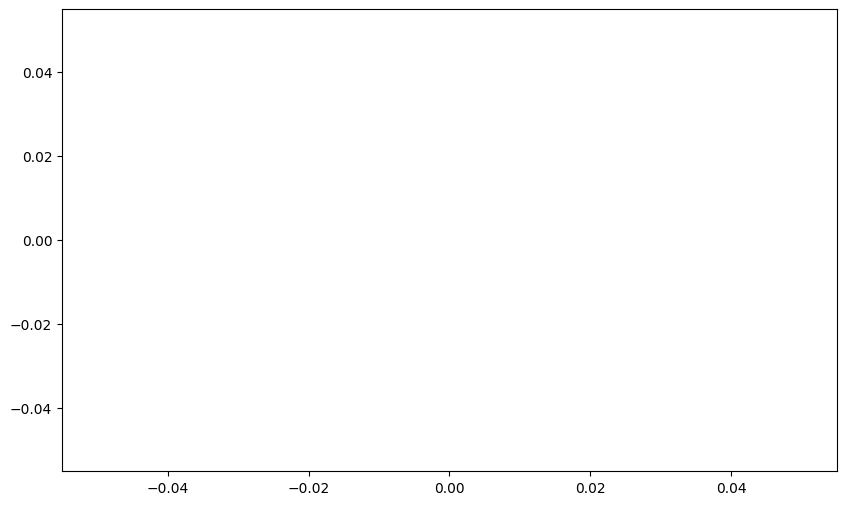

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(
    x=crime_data['Longitude'], 
    y=crime_data['Latitude'], 
    cmap="Reds", 
    fill=True, 
    bw_adjust=0.3,  # Adjust bandwidth
    thresh=0.01     # Set a threshold for density values
)
plt.title('Crime Density by Location', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
print(crime_data[['Longitude', 'Latitude']].describe())
print(crime_data[['Longitude', 'Latitude']].isnull().sum())


           Longitude       Latitude
count  530652.000000  530652.000000
mean     -110.495297      44.216029
std        37.329862      14.938004
min      -124.549757       0.000000
25%      -123.127194      49.235573
50%      -123.107128      49.264251
75%      -123.065932      49.280441
max         0.000000      49.755314
Longitude    0
Latitude     0
dtype: int64


In [24]:
crime_data = crime_data.dropna(subset=['Longitude', 'Latitude']).drop_duplicates(subset=['Longitude', 'Latitude'])


In [25]:
print(crime_data['Longitude'].nunique(), crime_data['Latitude'].nunique())


98972 101885


ValueError: Contour levels must be increasing

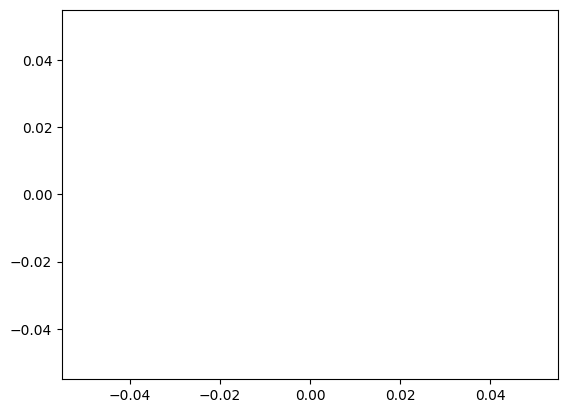

In [26]:
sns.kdeplot(
    x=crime_data['Longitude'],
    y=crime_data['Latitude'],
    cmap="Reds",
    fill=True,
    bw_adjust=0.1,  # Experiment with this value
    thresh=0.01
)


In [27]:
from scipy.stats import gaussian_kde
import numpy as np

x = crime_data['Longitude']
y = crime_data['Latitude']

xy = np.vstack([x, y])
z = gaussian_kde(xy, bw_method=0.3)(xy)

print(f"Density range: {z.min()} - {z.max()}")


Density range: 0.0015885792692251508 - 39.99067045974774


ValueError: Contour levels must be increasing

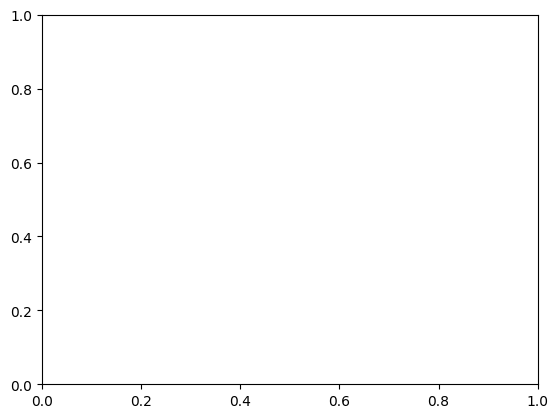

In [28]:
sns.kdeplot(
    x=crime_data['Longitude'],
    y=crime_data['Latitude'],
    cmap="Reds",
    fill=False,
    gridsize=100,  # Adjust as needed
    thresh=0.01
)


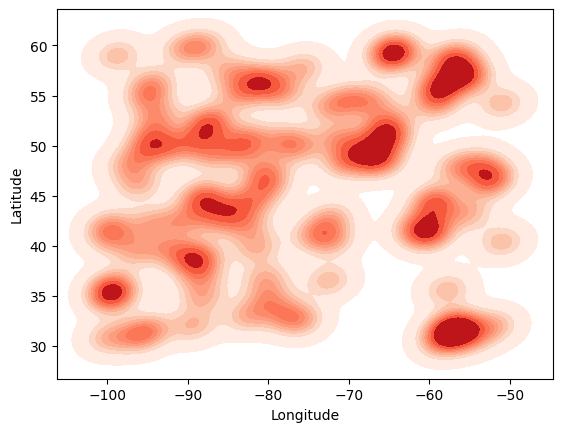

In [29]:
import pandas as pd

# Generate synthetic data
synthetic_data = pd.DataFrame({
    "Longitude": np.random.uniform(-100, -50, 100),
    "Latitude": np.random.uniform(30, 60, 100)
})

sns.kdeplot(
    x=synthetic_data['Longitude'],
    y=synthetic_data['Latitude'],
    cmap="Reds",
    fill=True,
    bw_adjust=0.3,
    thresh=0.01
)
plt.show()


ValueError: Contour levels must be increasing

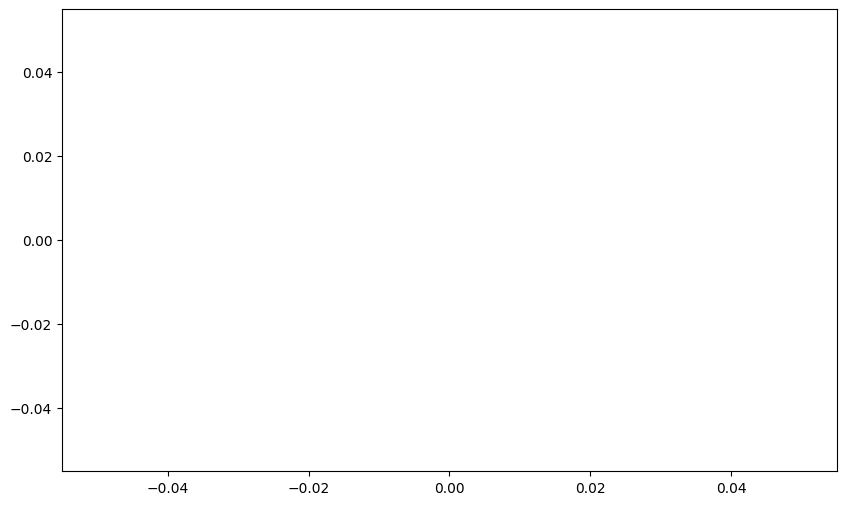

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(
    x=crime_data['Longitude'], 
    y=crime_data['Latitude'], 
    cmap="Reds", 
    fill=True, 
    bw_adjust=0.5
)
plt.title('Crime Density by Location', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\COE-27\AppData\Local\Temp\ipykernel_8488\2431961416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_crime.values, y=neighborhood_crime.index, palette='coolwarm')


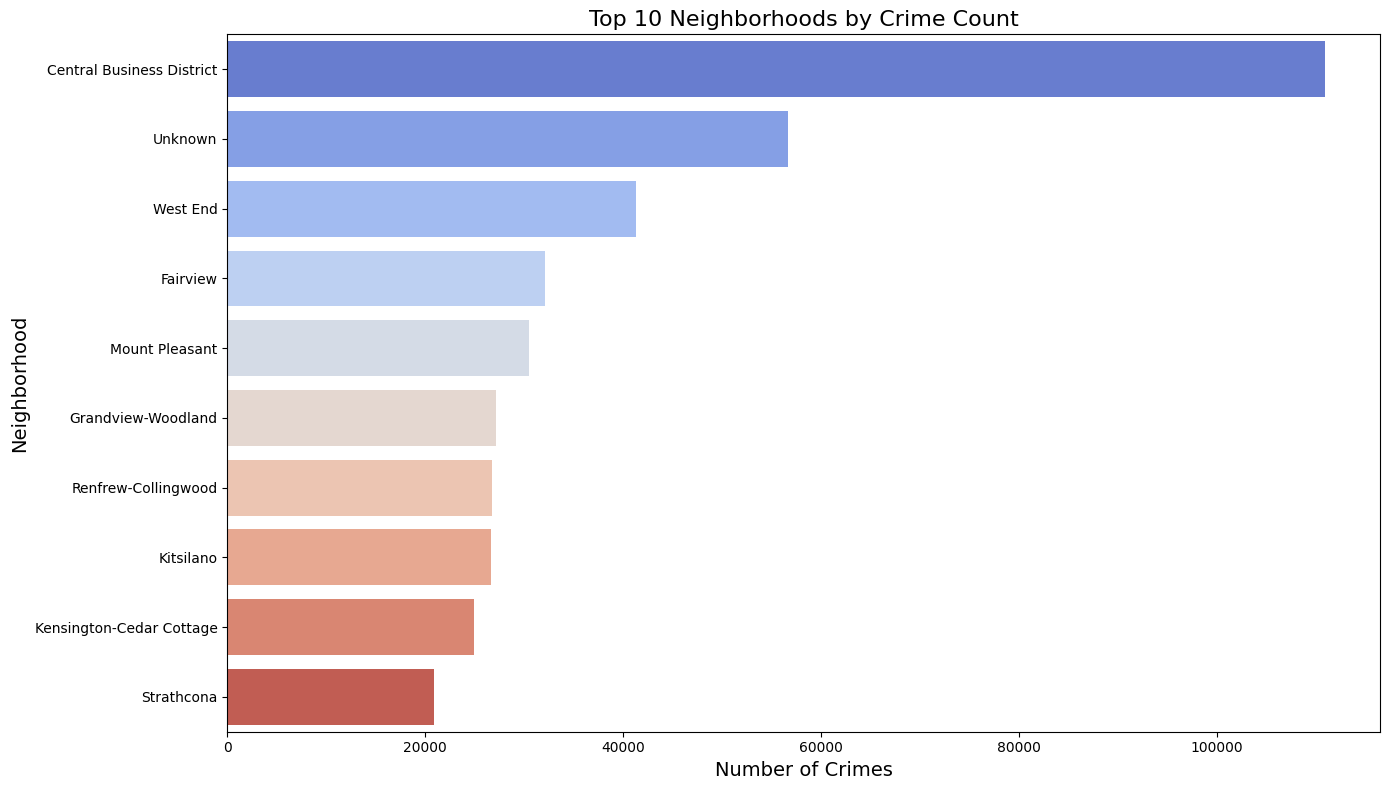

In [21]:
plt.figure(figsize=(14, 8))
neighborhood_crime = crime_data['NEIGHBOURHOOD'].value_counts().head(10)
sns.barplot(x=neighborhood_crime.values, y=neighborhood_crime.index, palette='coolwarm')
plt.title('Top 10 Neighborhoods by Crime Count', fontsize=16)
plt.xlabel('Number of Crimes', fontsize=14)
plt.ylabel('Neighborhood', fontsize=14)
plt.tight_layout()
plt.show()

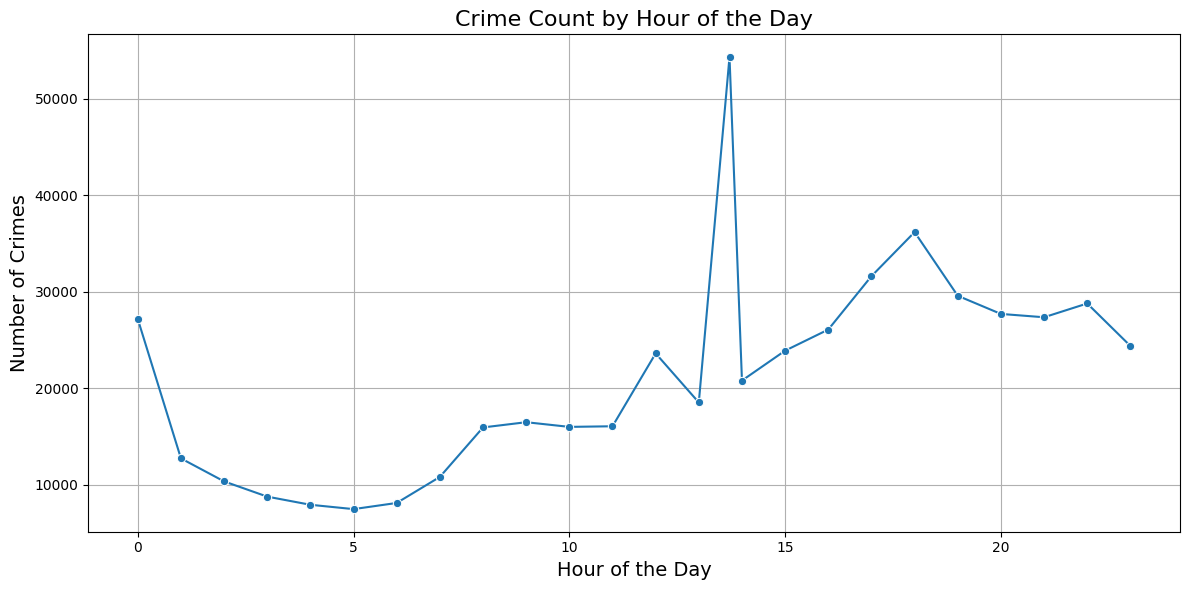

In [22]:
plt.figure(figsize=(12, 6))
hourly_crime = crime_data.groupby('HOUR').size()
sns.lineplot(x=hourly_crime.index, y=hourly_crime.values, marker='o')
plt.title('Crime Count by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Number of Crimes', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='YEAR'>

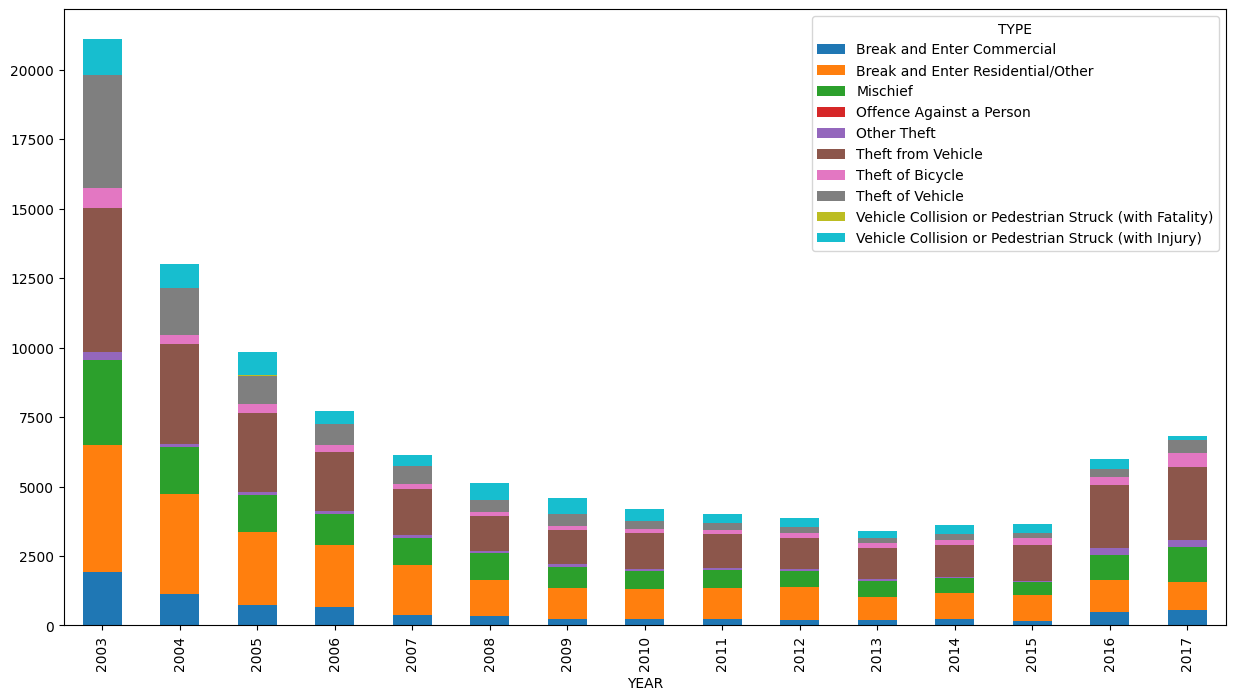

In [31]:
crime_data.groupby(['YEAR', 'TYPE']).size().unstack().plot(kind='bar', stacked=True, figsize=(15, 8))


In [35]:
print(crime_data[['Longitude', 'Latitude']].describe())
print(crime_data[['Longitude', 'Latitude']].isnull().sum())


           Longitude       Latitude
count  103015.000000  103015.000000
mean     -123.101623      49.251603
std         0.386322       0.155103
min      -124.549757       0.000000
25%      -123.135152      49.233890
50%      -123.101049      49.255034
75%      -123.065707      49.269620
max         0.000000      49.755314
Longitude    0
Latitude     0
dtype: int64


In [36]:
crime_data = crime_data.dropna(subset=['Longitude', 'Latitude'])
crime_data = crime_data[
    (crime_data['Longitude'] > -180) & (crime_data['Longitude'] < 180) &
    (crime_data['Latitude'] > -90) & (crime_data['Latitude'] < 90)
]


ValueError: Contour levels must be increasing

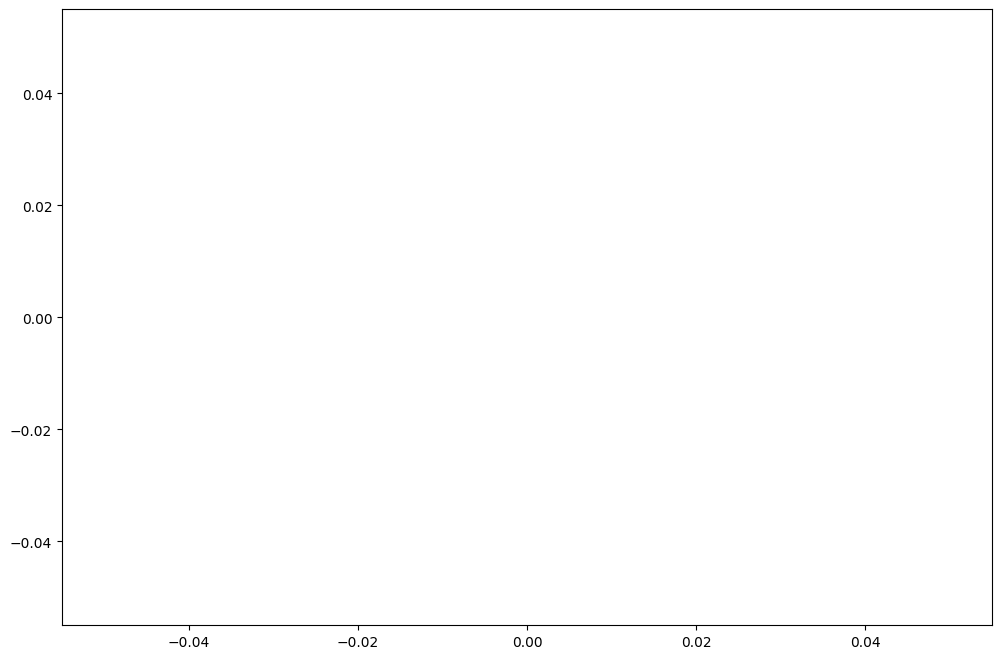

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.kdeplot(
    x=crime_data['Longitude'], 
    y=crime_data['Latitude'], 
    fill=True, 
    cmap="Reds", 
    bw_adjust=1,  # Increase smoothing
    levels=30     # Reduce the number of levels
)
plt.title("Crime Density by Location", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


<Axes: xlabel='Longitude', ylabel='Latitude'>

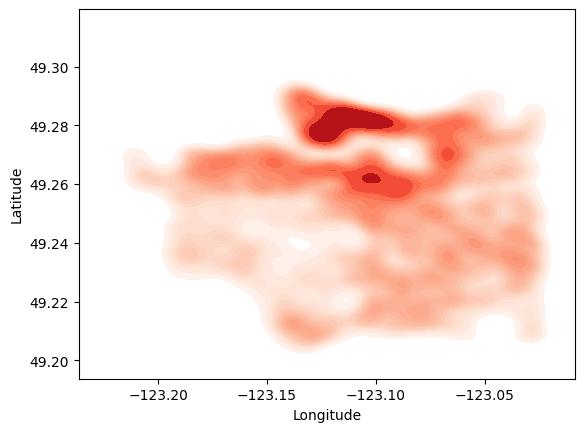

In [38]:
sample_data = crime_data.sample(10000, random_state=42)
sns.kdeplot(
    x=sample_data['Longitude'], 
    y=sample_data['Latitude'], 
    fill=True, 
    cmap="Reds", 
    bw_adjust=0.5, 
    levels=20
)


ValueError: Contour levels must be increasing

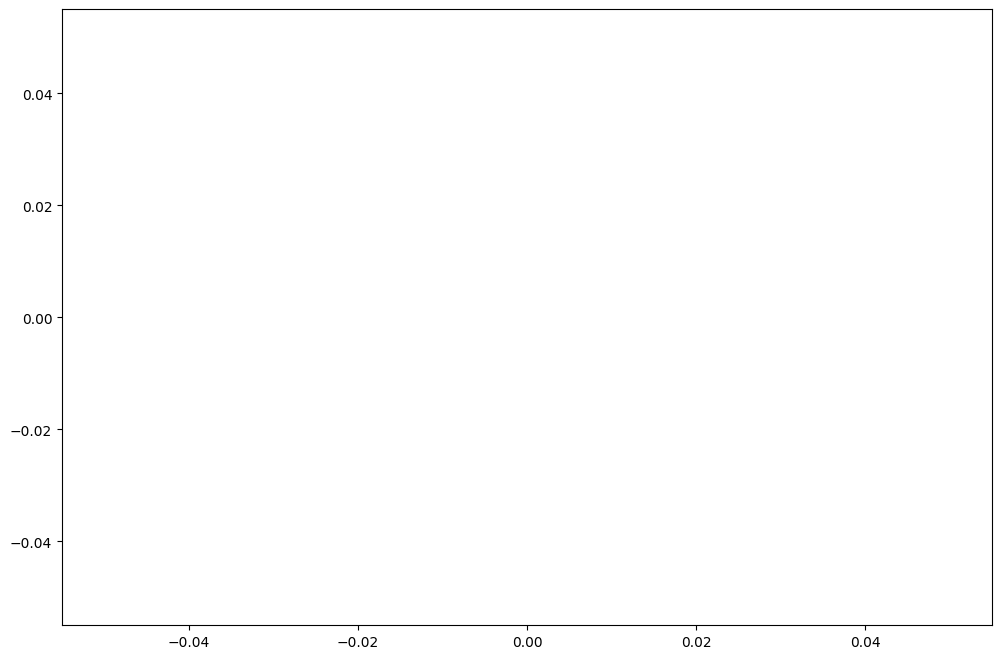

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.kdeplot(
    x=crime_data['Longitude'], 
    y=crime_data['Latitude'], 
    fill=True, cmap="Reds", bw_adjust=0.5, levels=100
)
plt.title("Crime Density by Location", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [33]:
from sklearn.cluster import DBSCAN
import numpy as np

coords = crime_data[['Latitude', 'Longitude']].dropna()
clustering = DBSCAN(eps=0.01, min_samples=5).fit(coords)
crime_data['Cluster'] = np.nan
crime_data.loc[coords.index, 'Cluster'] = clustering.labels_


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['YEAR', 'MONTH', 'DAY', 'HOUR', 'Latitude', 'Longitude']
X = crime_data[features].dropna()
y = crime_data['TYPE'].iloc[X.index]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))


IndexError: positional indexers are out-of-bounds

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Select features and target
features = ['YEAR', 'MONTH', 'DAY', 'HOUR', 'Latitude', 'Longitude']
target = 'TYPE'

# Drop rows with missing values in both features and target
crime_data_cleaned = crime_data.dropna(subset=features + [target]).reset_index(drop=True)

# Split into features (X) and target (y)
X = crime_data_cleaned[features]
y = crime_data_cleaned[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.37


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Selecting relevant features
features = ['YEAR', 'MONTH', 'DAY', 'HOUR', 'Latitude', 'Longitude']
X = crime_data[features].dropna().reset_index(drop=True)  # Clean data
y = crime_data.loc[X.index, 'TYPE'].reset_index(drop=True)  # Align target with features

# Encode target variable
y_encoded = y.astype('category').cat.codes

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model prediction and evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


KeyError: '[1, 2, 3, 4, 5, 8, 10, 17, 19, 23, 27, 31, 32, 33, 34, 35, 36, 37, 44, 47, 48, 49, 51, 52, 53, 58, 59, 60, 61, 62, 63, 64, 66, 67, 70, 72, 76, 77, 78, 80, 81, 82, 86, 89, 90, 91, 92, 93, 94, 96, 97, 98, 101, 105, 107, 111, 118, 119, 120, 121, 122, 123, 124, 128, 129, 130, 131, 132, 133, 135, 137, 138, 139, 141, 144, 145, 146, 149, 154, 155, 156, 157, 160, 161, 165, 168, 169, 170, 173, 175, 176, 177, 178, 181, 183, 184, 185, 186, 187, 188, 189, 190, 197, 198, 200, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 213, 214, 215, 217, 218, 219, 221, 224, 226, 228, 229, 230, 232, 233, 234, 236, 237, 239, 244, 245, 246, 249, 252, 253, 262, 266, 267, 268, 269, 270, 273, 274, 277, 278, 279, 280, 282, 284, 287, 288, 291, 292, 293, 294, 295, 296, 297, 298, 300, 301, 302, 303, 305, 310, 312, 313, 314, 315, 316, 318, 320, 321, 322, 323, 324, 327, 329, 330, 331, 332, 333, 335, 336, 338, 339, 341, 343, 344, 346, 347, 348, 351, 352, 353, 354, 357, 359, 362, 363, 364, 365, 367, 372, 376, 3

In [42]:
# Select relevant features and drop rows with missing values
features = ['YEAR', 'MONTH', 'DAY', 'HOUR', 'Latitude', 'Longitude']
X = crime_data[features].dropna()  # Do not reset the index yet

# Align the target variable with the cleaned feature set
y = crime_data.loc[X.index, 'TYPE']  # Match indices of X and y

# Encode target variable
y_encoded = y.astype('category').cat.codes

# Reset index for X and y for compatibility with ML libraries
X = X.reset_index(drop=True)
y_encoded = y_encoded.reset_index(drop=True)

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.32      0.36      2254
           1       0.41      0.56      0.48      7653
           2       0.26      0.13      0.18      4705
           4       0.30      0.08      0.13       485
           5       0.37      0.56      0.45      8975
           6       0.16      0.03      0.05      1183
           7       0.25      0.12      0.16      3340
           8       0.00      0.00      0.00        30
           9       0.28      0.09      0.13      2280

    accuracy                           0.37     30905
   macro avg       0.27      0.21      0.21     30905
weighted avg       0.34      0.37      0.33     30905

Confusion Matrix:
 [[ 731  314  206   15  827    8   96    0   57]
 [ 179 4320  394    7 2352   38  284    0   79]
 [ 304 1340  632   14 2102   24  197    0   92]
 [  31   90   41   40  226   10   14    0   33]
 [ 294 2346  631   31 5009   52  457    0  155]
 [  52  322 

C:\Users\COE-27\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\COE-27\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\COE-27\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
crime_data['hour_sin'] = np.sin(2 * np.pi * crime_data['HOUR'] / 24)
crime_data['hour_cos'] = np.cos(2 * np.pi * crime_data['HOUR'] / 24)


<Figure size 1500x800 with 0 Axes>

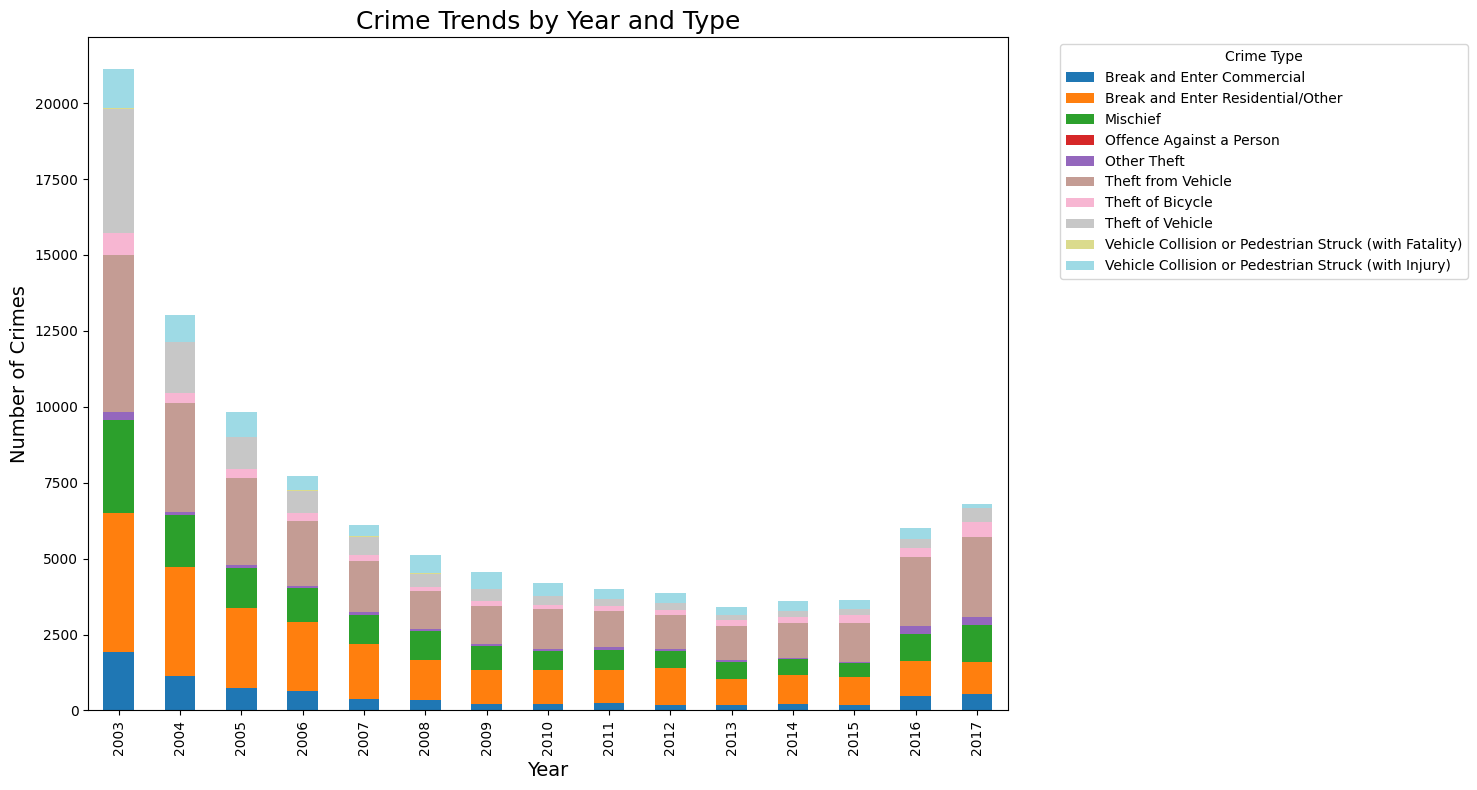

In [46]:
#Improved Code for Crime Trends Analysis
import matplotlib.pyplot as plt

# Group data by YEAR and TYPE to get crime counts
crime_trends = crime_data.groupby(['YEAR', 'TYPE']).size().unstack()

# Plotting the trends
plt.figure(figsize=(15, 8))
crime_trends.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='tab20')
plt.title("Crime Trends by Year and Type", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


C:\Users\COE-27\AppData\Local\Temp\ipykernel_8488\913914367.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crime_percentage_change = crime_trends.pct_change().fillna(0) * 100


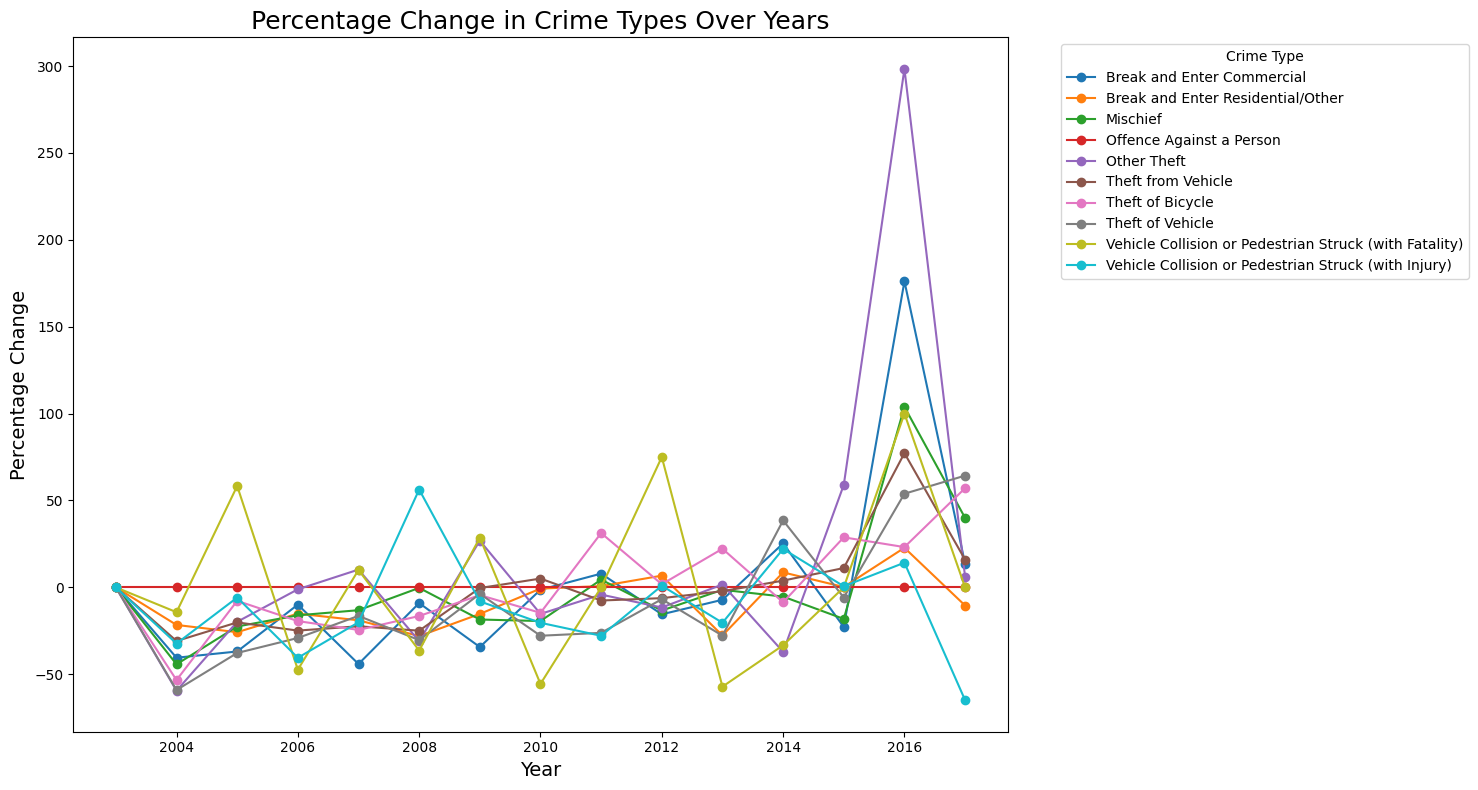

In [47]:
crime_percentage_change = crime_trends.pct_change().fillna(0) * 100
crime_percentage_change.plot(kind='line', figsize=(15, 8), marker='o')
plt.title("Percentage Change in Crime Types Over Years", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Percentage Change", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


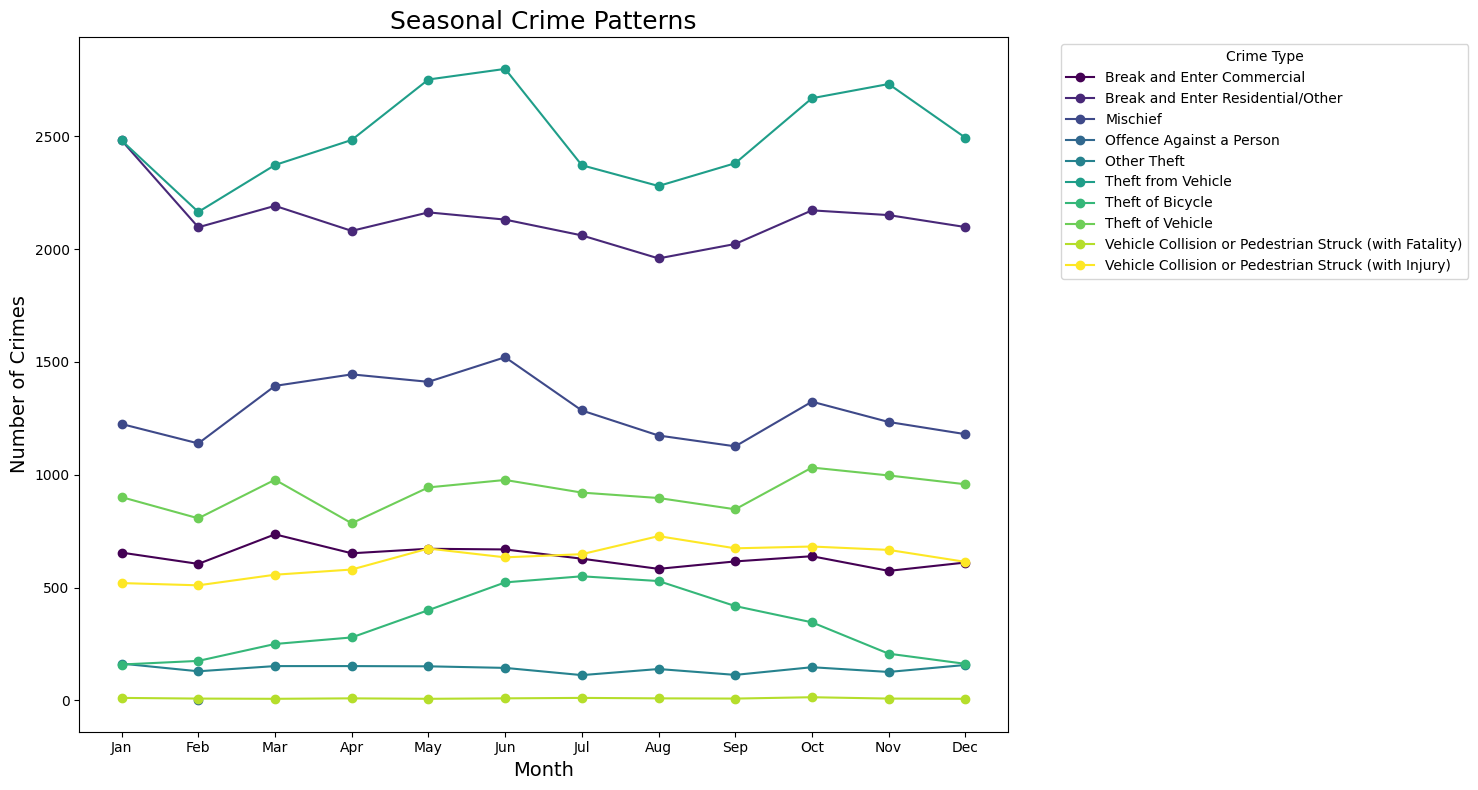

In [48]:
monthly_trends = crime_data.groupby(['MONTH', 'TYPE']).size().unstack()
monthly_trends.plot(kind='line', figsize=(15, 8), marker='o', colormap='viridis')
plt.title("Seasonal Crime Patterns", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xticks(range(1, 13), 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()


In [49]:
specific_crimes = ['Assault', 'Burglary', 'Theft']  # Replace with actual types
specific_trends = crime_data[crime_data['TYPE'].isin(specific_crimes)]
specific_trends = specific_trends.groupby(['YEAR', 'TYPE']).size().unstack()

specific_trends.plot(kind='line', figsize=(15, 8), marker='o', colormap='coolwarm')
plt.title("Trends for Specific Crime Types", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


TypeError: no numeric data to plot

In [51]:
print(specific_trends.head())
# Check for numeric columns in specific_trends
print(specific_trends.dtypes)


Empty DataFrame
Columns: []
Index: []
Series([], dtype: object)


In [52]:
specific_trends = specific_trends.reset_index()


In [53]:
print(crime_data['TYPE'].unique())  # List all unique crime types


['Other Theft' 'Break and Enter Residential/Other' 'Mischief'
 'Break and Enter Commercial' 'Offence Against a Person'
 'Theft from Vehicle'
 'Vehicle Collision or Pedestrian Struck (with Injury)'
 'Vehicle Collision or Pedestrian Struck (with Fatality)'
 'Theft of Vehicle' 'Theft of Bicycle']


Empty DataFrame
Columns: [YEAR]
Index: []


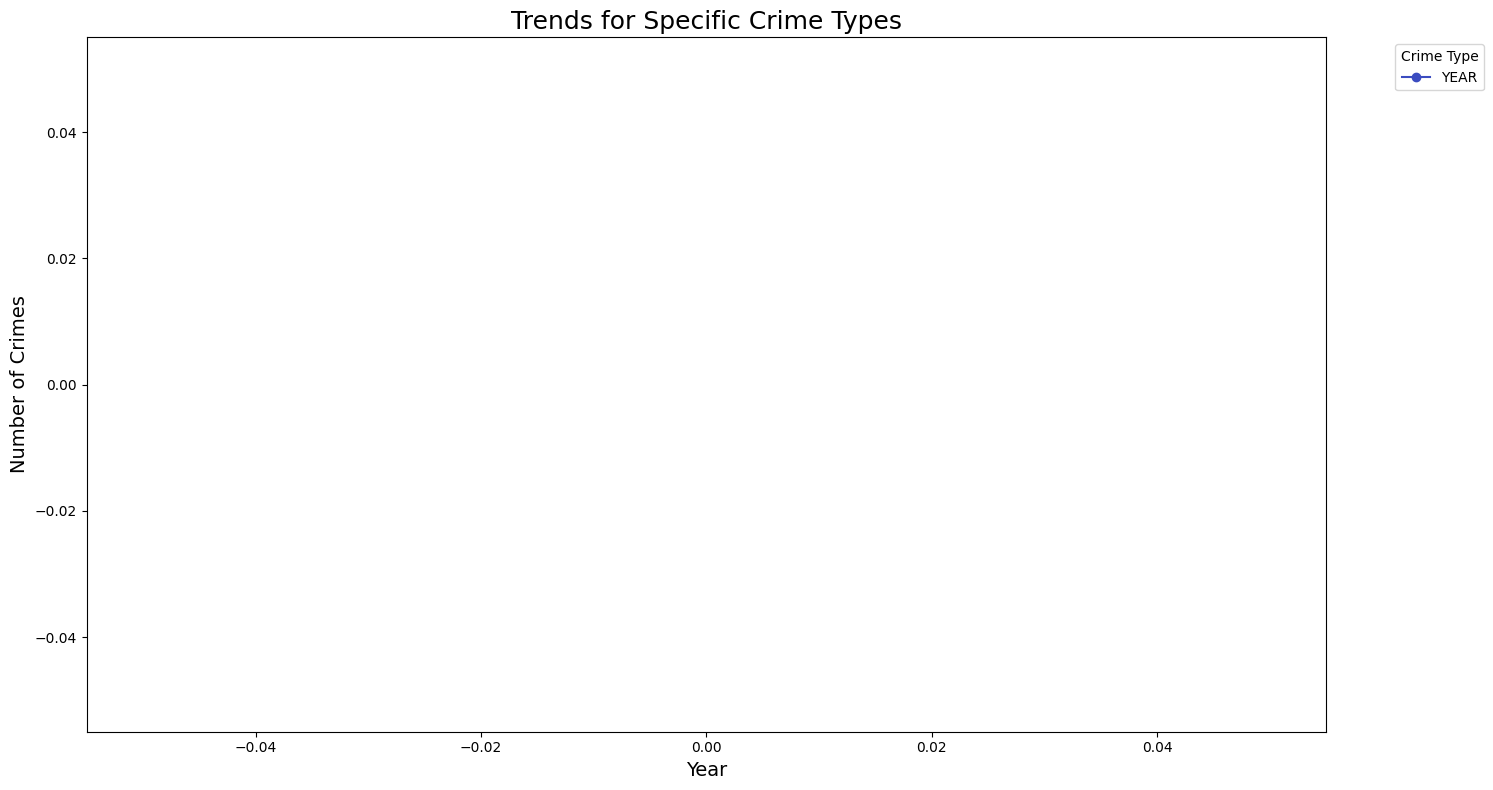

In [55]:
# Ensure that specific_trends is in the correct format
specific_trends = crime_data[crime_data['TYPE'].isin(specific_crimes)]
specific_trends = specific_trends.groupby(['YEAR', 'TYPE']).size().unstack().reset_index()

specific_trends = specific_trends.fillna(0)  # Replace NaN with 0


# Check the structure of the data before plotting
print(specific_trends.head())

# Plot the trends
specific_trends.plot(kind='line', figsize=(15, 8), marker='o', colormap='coolwarm')
plt.title("Trends for Specific Crime Types", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [56]:
print(specific_trends.shape)  # This will show the number of rows and columns
print(specific_trends.head())  # Check the first few rows


(0, 1)
Empty DataFrame
Columns: [YEAR]
Index: []


In [57]:
print(crime_data['TYPE'].unique())  # List all unique crime types


['Other Theft' 'Break and Enter Residential/Other' 'Mischief'
 'Break and Enter Commercial' 'Offence Against a Person'
 'Theft from Vehicle'
 'Vehicle Collision or Pedestrian Struck (with Injury)'
 'Vehicle Collision or Pedestrian Struck (with Fatality)'
 'Theft of Vehicle' 'Theft of Bicycle']


In [58]:
specific_trends = specific_trends.groupby(['YEAR', 'TYPE']).size().unstack().reset_index()
print(specific_trends.head())


KeyError: 'TYPE'

In [59]:
print(specific_trends.isna().sum())  # Check for missing data in specific_trends
specific_trends = specific_trends.fillna(0)  # Optionally replace NaN with 0


TYPE
YEAR    0
dtype: int64


IndexError: index 0 is out of bounds for axis 0 with size 0

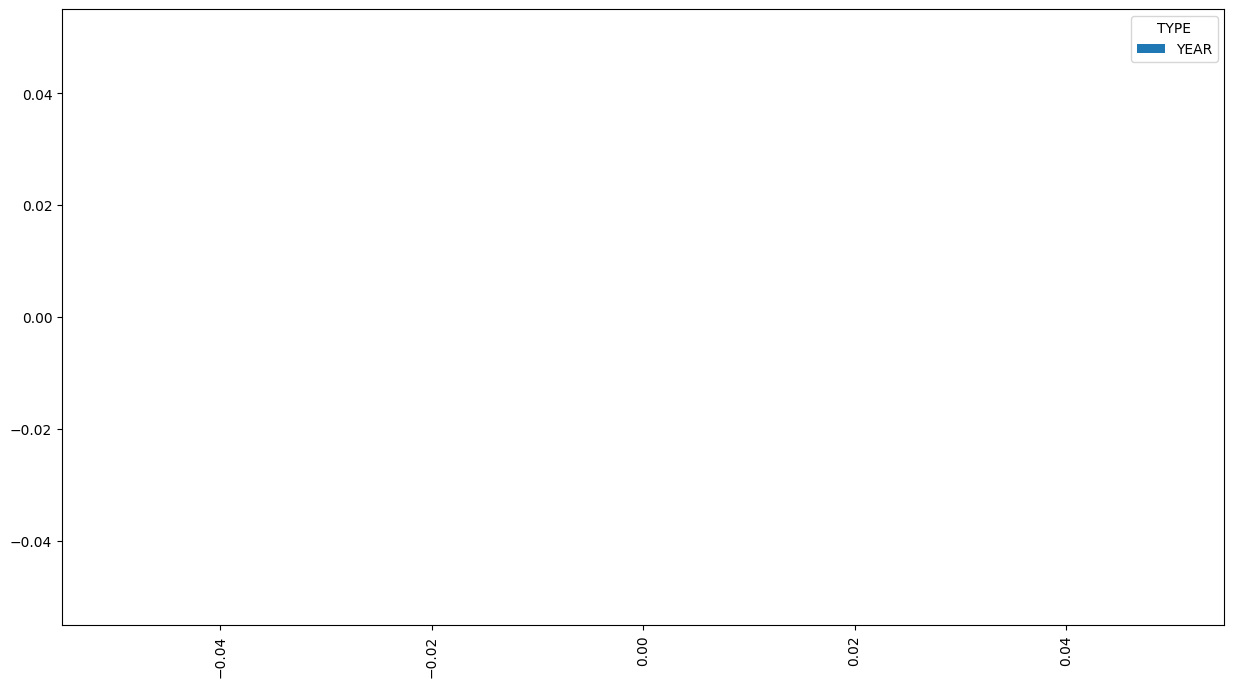

In [60]:
specific_trends.plot(kind='bar', figsize=(15, 8))
plt.title("Trends for Specific Crime Types", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


(0, 16)
Empty DataFrame
Columns: [TYPE, YEAR, MONTH, DAY, HOUR, MINUTE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y, Latitude, Longitude, DAY_OF_WEEK, Cluster, hour_sin, hour_cos]
Index: []
Empty DataFrame
Columns: [YEAR]
Index: []


IndexError: index 0 is out of bounds for axis 0 with size 0

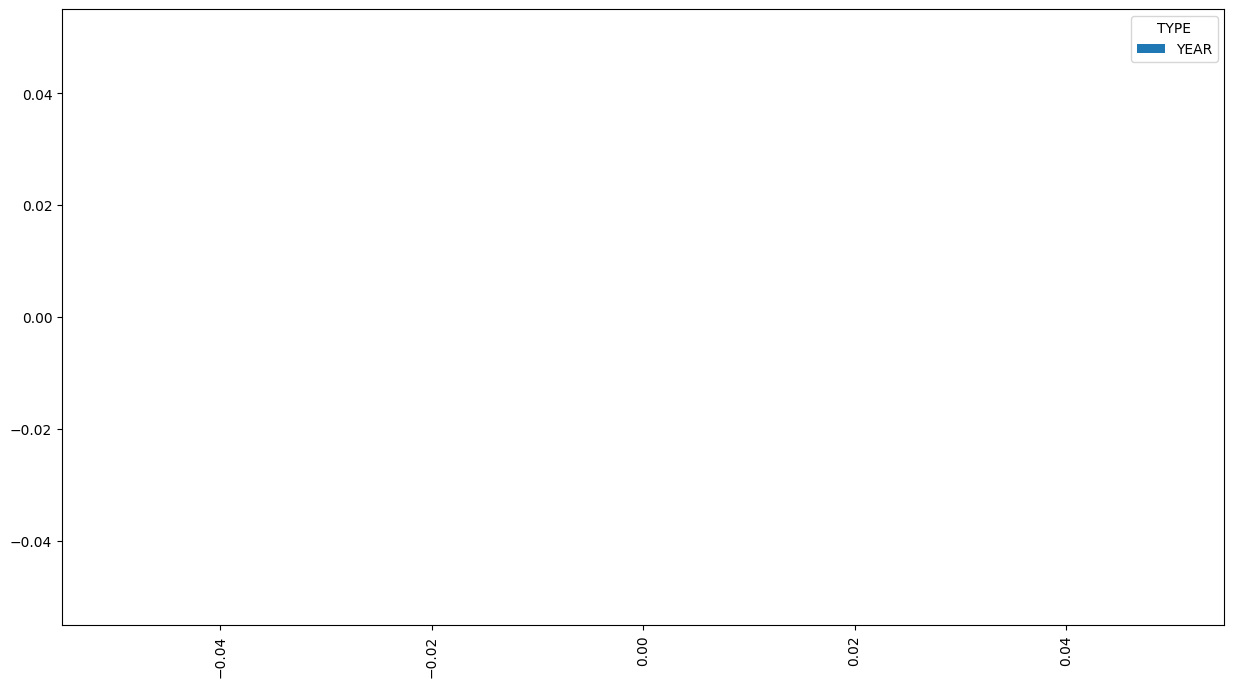

In [61]:
# Filter the dataset for specific crime types
specific_trends = crime_data[crime_data['TYPE'].isin(specific_crimes)]

# Check if there is any data for the specific crimes
print(specific_trends.shape)  # Check rows and columns
print(specific_trends.head())  # Check first few rows

# Group by YEAR and TYPE, and ensure it's in numeric form for plotting
specific_trends = specific_trends.groupby(['YEAR', 'TYPE']).size().unstack().reset_index()
print(specific_trends.head())  # Check if it's aggregated correctly

# Handle missing data by filling NaN values with 0
specific_trends = specific_trends.fillna(0)

# Plot the trends as a bar chart first for verification
specific_trends.plot(kind='bar', figsize=(15, 8))
plt.title("Trends for Specific Crime Types", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Optionally, plot the trends as a line chart if the bar chart works
specific_trends.plot(kind='line', figsize=(15, 8), marker='o', colormap='coolwarm')
plt.title("Trends for Specific Crime Types", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Crimes", fontsize=14)
plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [62]:
# Check if the filtered DataFrame has data
print("Shape of specific_trends:", specific_trends.shape)
print(specific_trends.head())


Shape of specific_trends: (0, 1)
Empty DataFrame
Columns: [YEAR]
Index: []


In [63]:
print(crime_data['TYPE'].unique())  # Check all unique crime types in the data


['Other Theft' 'Break and Enter Residential/Other' 'Mischief'
 'Break and Enter Commercial' 'Offence Against a Person'
 'Theft from Vehicle'
 'Vehicle Collision or Pedestrian Struck (with Injury)'
 'Vehicle Collision or Pedestrian Struck (with Fatality)'
 'Theft of Vehicle' 'Theft of Bicycle']


In [64]:
if not specific_trends.empty:
    specific_trends.plot(kind='bar', figsize=(15, 8))
    plt.title("Trends for Specific Crime Types", fontsize=18)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Number of Crimes", fontsize=14)
    plt.legend(title="Crime Type", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot for the selected crime types.")


No data available to plot for the selected crime types.


In [65]:
specific_trends = specific_trends.groupby(['YEAR', 'TYPE']).size().unstack()
print(specific_trends.head())  # Ensure the grouping is correct and there's data


KeyError: 'TYPE'